# Predicción de satisfacción de clientes en vuelos

*1. Objetivo General del Proyecto*

El objetivo de este trabajo es construir modelos predictivos basados en algoritmos de machine learning capaces de clasificar el nivel de satisfacción de los pasajeros de una aerolínea. Al predecir si un cliente estaría satisfecho o no en base a variables demográficas (como edad o género), características del vuelo (distancia, clase, tipo de viaje) y la evaluación de distintos servicios (wifi, comida, confort, atención, retrasos), la aerolínea podría identificar qué factores impactarían más en la experiencia del cliente.

Esta investigación tiene una naturaleza probabilística, ya que buscaríamos estimar la probabilidad de pertenencia a una cierta clase de satisfacción, permitiendo a la empresa plantear estrategias hipotéticas para mejorar sus servicios y fidelizar clientes.

*2. Contexto del Problema*

Una aerolínea opera con decenas de miles de vuelos anuales, transportando aproximadamente 130,000 pasajeros en un período analizado. El desafío principal sería identificar qué pasajeros tendrían experiencias insatisfactorias durante sus vuelos para implementar intervenciones preventivas que mejorarían la experiencia del cliente.

Actualmente, la empresa desconoce cuáles son los pasajeros en riesgo de insatisfacción hasta después de que vuelan, cuando es demasiado tarde para actuar. Esta falta de información anticipada generaría consecuencias negativas significativas:

* Pérdida de clientes leales que no retornarían tras una mala experiencia
* Críticas negativas en redes sociales que afectarían la reputación de la marca
* Menor probabilidad de recompra de servicios en futuros viajes
* Oportunidades perdidas de retención de clientes de alto valor

Estas limitaciones operacionales resaltan la importancia de contar con un sistema predictivo que permitiría actuar de manera preventiva antes de que el cliente aborde el avión.

*3. Aplicación Práctica y Caso de Uso*

Los dos modelos propuestos se implementarían en el sistema de gestión de reservas de la aerolínea, integrándose directamente en el flujo operativo. Al utilizar dos enfoques analíticos complementarios, el sistema evaluaría automáticamente el riesgo de insatisfacción basándose en las características personales, del viaje y servicios relevantes. Se plantea la hipótesis de que la comparación o combinación de estos modelos brindaría una mayor solidez en las predicciones.

*3.1 Estrategia de Intervención para Pasajeros de Alto Riesgo*

Para los pasajeros que resultarían clasificados como "Alto Riesgo", el sistema dispararía automáticamente un conjunto de acciones preventivas destinadas a mejorar su experiencia:

* Ofertas de upgrade automático a una clase superior, siempre que el margen comercial lo permitiera
* Asignación de asientos preferentes tales como ventana, pasillo o ubicación estratégica
* Provisión de vouchers para comida y bebida mejorada durante el vuelo
* Atención personalizada durante el proceso de check-in, con prioridad sobre otros pasajeros
* Otorgamiento de puntos de lealtad adicionales, multiplicando el valor de recompensa
* Llamada de bienvenida y confirmación del equipo de atención al cliente
* Prioridad en el proceso de boarding y descenso del avión

*3.2 Estrategia para Pasajeros de Bajo Riesgo*

Para los pasajeros que serían clasificados como "Bajo Riesgo", se mantendría el servicio estándar sin inversiones adicionales, optimizando así el uso de recursos de la empresa.

*4. Beneficios Esperados*

La implementación de estos modelos predictivos representaría una oportunidad de mejora significativa en múltiples dimensiones del negocio:

* Retención de Clientes. Al identificar pasajeros en riesgo, se plantea la hipótesis de que una intervención preventiva temprana podría mitigar el malestar. A futuro, se debería validar empíricamente si estas acciones lograrían efectivamente reducir la tasa de churn y evitar el abandono del cliente.
* Aumento de Ingresos. Los clientes que recibirían atención personalizada y mejora de servicios tenderían a gastar más en futuros viajes, generando ingresos adicionales por recompra y servicios complementarios.
* Optimización de Costos. Dirigiendo recursos y mejoras solo a clientes en riesgo, se maximizaría el retorno de inversión en comparación con un enfoque de mejora generalizada para todos los pasajeros.
* Eficiencia Operativa. La automatización de decisiones basada en las predicciones de los modelos reduciría la necesidad de intervención manual y permitiría que el equipo se enfocara en casos complejos.
* Ventaja Competitiva. Diferenciarse mediante experiencias personalizadas basadas en datos sería un elemento diferenciador en una industria altamente competitiva.
* Análisis Estratégico. Los modelos permitirían identificar qué variables tendrían mayor impacto en la satisfacción, informando posibles decisiones hipotéticas sobre mejoras de servicios a nivel organizacional.

---
## Importación de librerías

In [1]:
from pathlib import Path
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

In [2]:
def plot_distributions(df, columns, kind='hist', target=None, figsize=(18, 14), cols=3, **kwargs):
    import math
    rows = math.ceil(len(columns) / cols)
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)
    axes = axes.flatten() if type(axes) == np.ndarray else [axes]
    for idx, col in enumerate(columns):
        if kind == 'hist':
            sns.histplot(data=df, x=col, hue=target, ax=axes[idx], **kwargs)
        elif kind == 'count':
            sns.countplot(data=df, x=col, hue=target, ax=axes[idx], **kwargs)
        elif kind == 'box':
            sns.boxplot(data=df, y=col, x=target, ax=axes[idx], **kwargs)
        axes[idx].set_title(col, fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('')
    # Ocultar ejes sobrantes
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)
    plt.tight_layout()
    plt.show()


---
## Carga de datos

In [3]:
def load_airline_data():
    csv_path = Path.home() / "Downloads" / "Invistico_Airline.csv"
    
    if not csv_path.is_file():
        csv_path.parent.mkdir(parents=True, exist_ok=True)
        url = "https://github.com/AgustinaHourcade/airline-passenger-satisfaction/blob/main/Invistico_Airline.csv"
        urllib.request.urlretrieve(url, csv_path)
        
    return pd.read_csv(csv_path)

df = load_airline_data()

print(f"Forma del dataset: {df.shape}")
display(df.head(10))

Forma del dataset: (129880, 23)


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Male,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Female,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Male,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Female,Loyal Customer,56,Personal Travel,Business,73,0,0,0,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Male,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,...,2,2,2,4,5,3,4,2,30,26.0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nVariables numéricas ({len(numeric_cols)}): {numeric_cols}\n")
print(f"Variables categóricas ({len(categorical_cols)}): {categorical_cols}")


Variables numéricas (18): ['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Variables categóricas (5): ['satisfaction', 'Gender', 'Customer Type', 'Type of Travel', 'Class']


--- 
## Distribución de las variables

In [6]:
print("\nEstadísticas descriptivas de variables numéricas")
display(df[numeric_cols].describe())


Estadísticas descriptivas de variables numéricas


,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


<Figure size 640x480 with 0 Axes>

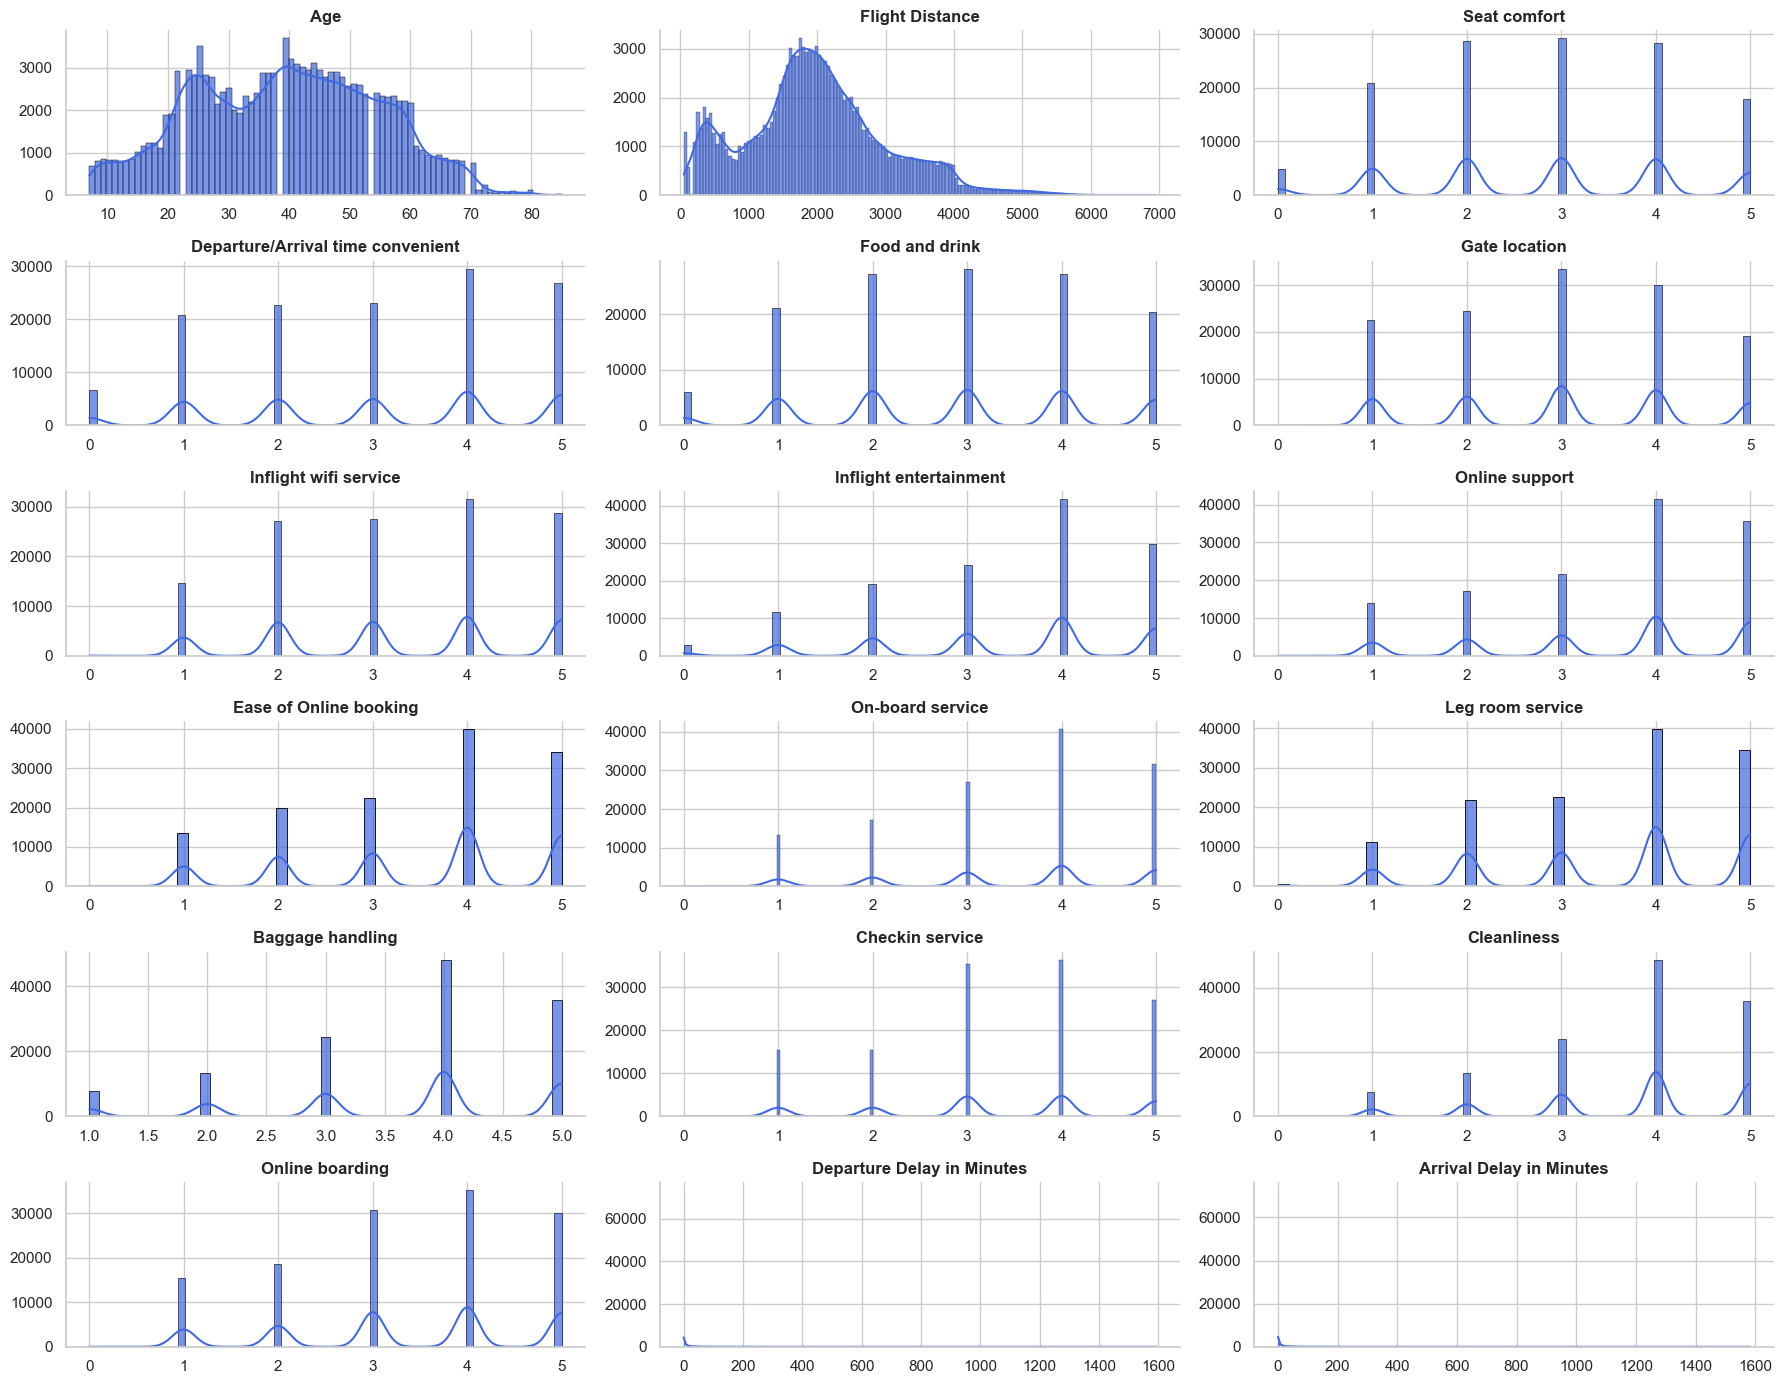

In [7]:
plt.suptitle('Distribuciones de variables numéricas\n', fontsize=16, fontweight='bold')
plot_distributions(df, numeric_cols, kind='hist', color='royalblue', edgecolor='black', alpha=0.7, kde=True)


**Age**: El rango de edad de los pasajeros va desde los 7 hasta los 85 años, con una media de 39.4 años y una mediana de 40. Al observar su histograma, vemos una distribución que no es perfectamente simétrica, mostrando un volumen importante de pasajeros en el rango de los 35 a los 50 años, y otro pico en pasajeros más jóvenes (alrededor de los 25 años)

**Flight Distance**: Presenta una alta dispersión (desvío estándar de 1027) con vuelos que van desde distancias muy cortas (50 km/millas) hasta vuelos de larga distancia (6951). El 50% de los vuelos (mediana) recorren 1925 o menos. Su histograma muestra una clara distribución asimétrica hacia la derecha (sesgo positivo), con una gran concentración de vuelos en el rango de los 1500 a 2500, y una "cola larga" hacia los valores máximos

**Departure Delay in Minutes** y **Arrival Delay in Minutes**: Ambas variables tienen un comportamiento idéntico a nivel descriptivo. La gran mayoría de los vuelos no presentan demoras significativas: la mediana es de 0 minutos y el percentil 75 es de apenas 12 y 13 minutos, respectivamente. Sin embargo, las medias (14.7 y 15.09 minutos) se ven fuertemente arrastradas hacia arriba por la presencia de valores atípicos (outliers) extremos, con demoras máximas que superan los 1580 minutos (más de 26 horas).
Observando la fila count, casi todas las variables tienen 129.880 registros, pero Arrival Delay in Minutes tiene solo 129.487. Esto confirma la presencia de 393 valores nulos en esta columna, los cuales deberán ser imputados.

Encuestas de servicios: Prácticamente todos los servicios se evalúan en una escala del 0 al 5, a excepción de Baggage handling, cuyo valor mínimo registrado es 1.
Servicios con mejor valoración (Media alta): Variables logísticas e interactivas como **Baggage handling** (media 3.69), **Cleanliness** (3.70) y **Online support** (3.51) son los mejores puntuados. En sus histogramas se evidencia un fuerte sesgo a la izquierda, ya que las barras correspondientes a las puntuaciones 4 y 5 concentran la gran mayoría de las respuestas

Servicios con valoración moderada/baja (Media baja): Aspectos clave del confort a bordo como **Seat comfort** (media 2.83) y **Food and drink** (2.85) presentan los promedios más bajos del dataset. Sus histogramas revelan distribuciones mucho más dispersas y uniformes, con una gran cantidad de calificaciones en 1, 2 y 3, lo que indica que estos son los principales puntos de dolor o insatisfacción general de los pasajeros

Servicios polarizados: Características como **Ease of Online booking** (media 3.47) u **On-board service** (media 3.46) muestran distribuciones donde, si bien las puntuaciones 4 y 5 son dominantes, existen picos notorios en las valoraciones más bajas (1 y 2) y vacíos en las valoraciones medias, demostrando que la experiencia en estos servicios rara vez es neutral

Servicios de conveniencia y logística (Valoración neutral): **Departure/Arrival time convenient** y **Gate location** presentan un comportamiento central casi perfecto. Tienen una media idéntica de 2.99 y una mediana (percentil 50) de 3.00, lo que indica que el centro de la distribución se ubica exactamente a la mitad de la escala de la encuesta. Sus cuartiles (el percentil 25% en 2 y el 75% en 4) confirman que sus distribuciones son muy simétricas y carecen de sesgos fuertes, reflejando una opinión general puramente neutral.

Servicios digitales y de entretenimiento (Valoración media-alta): **Inflight entertainment** (media 3.38), **Online boarding** (media 3.35) e **Inflight wifi service** (media 3.24) muestran un rendimiento de moderado a positivo. El entretenimiento a bordo y el embarque online tienen una mediana de 4.00, lo que significa que al menos la mitad de los pasajeros otorgaron puntuaciones altas. El servicio de wifi, aunque tiene una valoración general positiva, se queda con una mediana de 3.00, evidenciando una mayor presencia de calificaciones bajas o neutras en comparación a los otros dos servicios digitales.

Servicios de experiencia física y en tierra (Valoración media-alta): **Leg room service** presenta una media de 3.48 y una mediana de 4.00, con un tercer cuartil (percentil 75%) de 5.00. Esto sugiere fuertemente que hay un gran volumen de clientes que otorgó la calificación máxima posible, empujando la mayor densidad de los datos hacia los valores más altos. Por su parte, **Checkin service**, con una media de 3.34 y una mediana de 3.00, destaca por tener un rango intercuartílico (IQR) muy concentrado (entre 3 y 4). Esto significa que la inmensa mayoría de las respuestas se agrupan firmemente en esos valores, con muy pocas opiniones extremas, reflejando una experiencia estandarizada para casi todos los pasajeros.

In [8]:
print("\nAnálisis de variables categóricas")
for col in categorical_cols:
    print("\n", df[col].value_counts())


Análisis de variables categóricas

 satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

 Gender
Female    65899
Male      63981
Name: count, dtype: int64

 Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

 Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

 Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

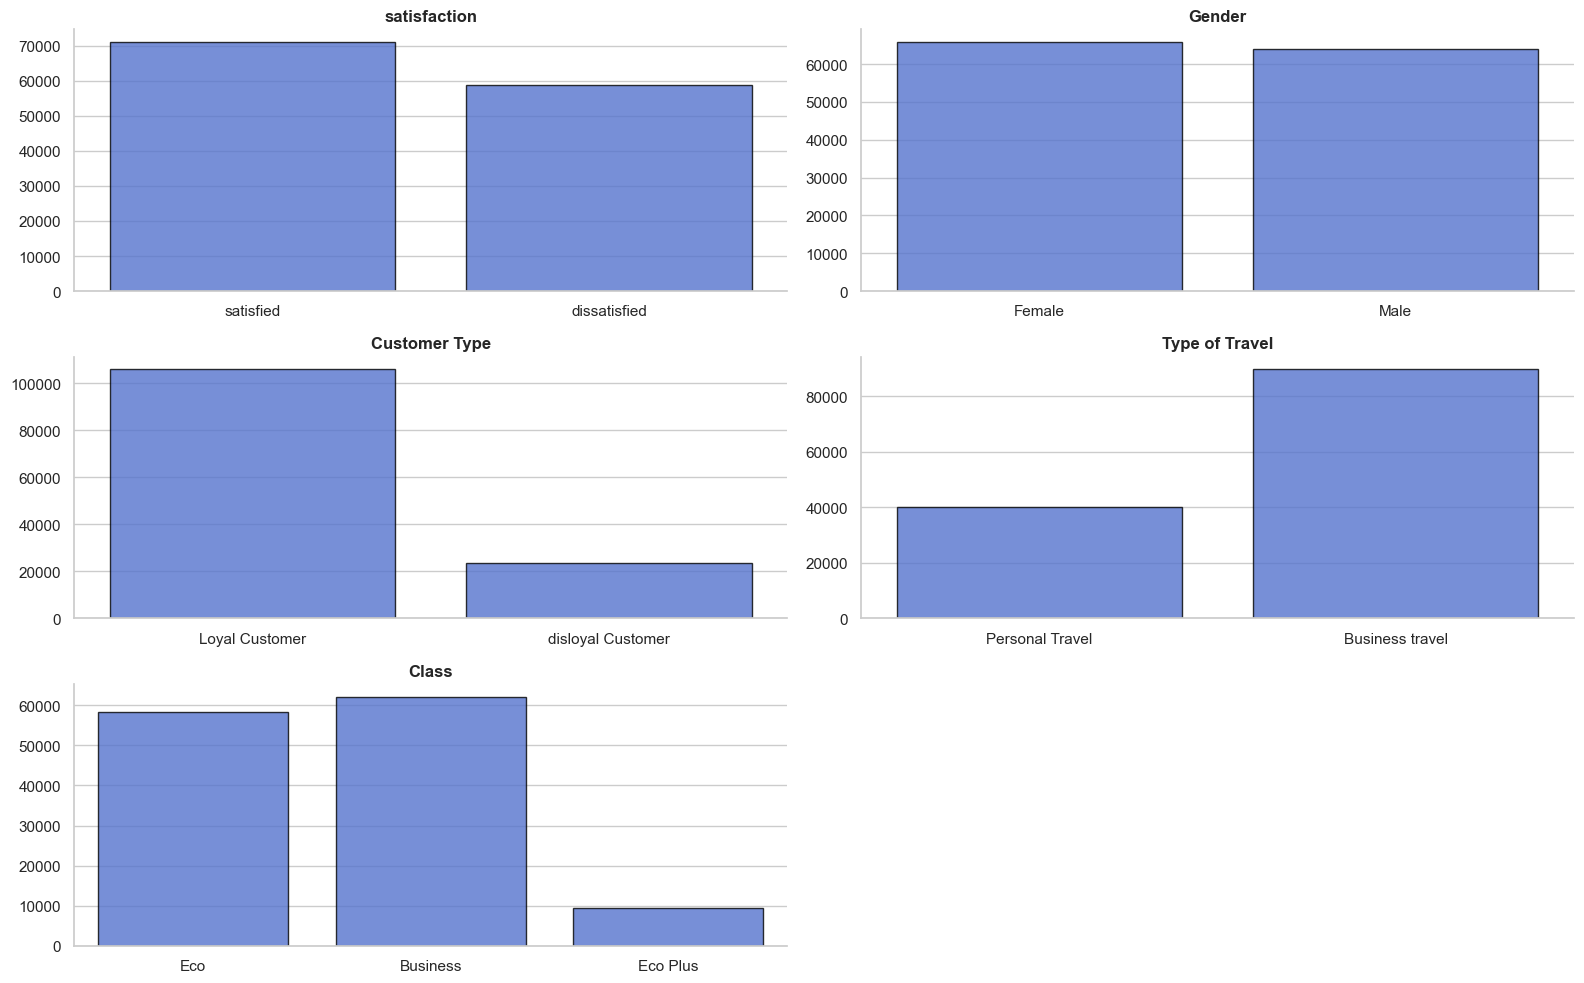

In [9]:
plt.suptitle('Distribuciones de variables categóricas\n', fontsize=16, fontweight='bold')
plot_distributions(df, categorical_cols, kind='count', color='royalblue', alpha=0.8, edgecolor='black', figsize=(16, 10), cols=2)


**Gender**: La distribución por género es sumamente equilibrada, casi simétrica. Contamos con 65.899 pasajeras femeninas y 63.981 pasajeros masculinos, lo que representa prácticamente un escenario de 50/50. Esto es un hallazgo muy positivo para el posterior modelado, ya que asegura que los algoritmos de machine learning no tendrán un sesgo de volumen hacia un género en particular al momento de aprender patrones.

**Customer Type**: A diferencia del género, esta variable presenta un fuerte desbalance en sus frecuencias. La inmensa mayoría de los registros corresponde a clientes leales o fidelizados (Loyal Customer con 106.100 observaciones), superando ampliamente a los clientes ocasionales (disloyal Customer con apenas 23.780). Aunque es un comportamiento esperable en la industria aerocomercial debido a los programas de pasajeros frecuentes, es importante tener en cuenta que los modelos aprenderían predominantemente del comportamiento de la base de clientes fieles.

**Type of Travel**: El gráfico de barras revela una clara predominancia de los viajes por motivos de negocios (Business travel) con 89.693 pasajeros, cifra que representa más del doble respecto a los viajes por motivos personales (Personal Travel con 40.187). Este perfil fuertemente corporativo sugiere que las expectativas generales del dataset podrían estar sesgadas hacia las necesidades de un viajero de negocios (como puntualidad y conectividad).

**Class**: La distribución por cabina muestra que el grueso de los pasajeros se divide en dos grandes bloques de tamaño similar: la clase ejecutiva (Business con 62.160 pasajeros) y la clase económica tradicional (Eco con 58.309 pasajeros). En contraste, la clase económica superior (Eco Plus) agrupa a una minoría muy reducida de solo 9.411 pasajeros. Visualmente, esto confirma que el servicio Eco Plus es un producto de nicho o con muy baja adopción dentro de este conjunto de datos comparado con las dos clases principales.

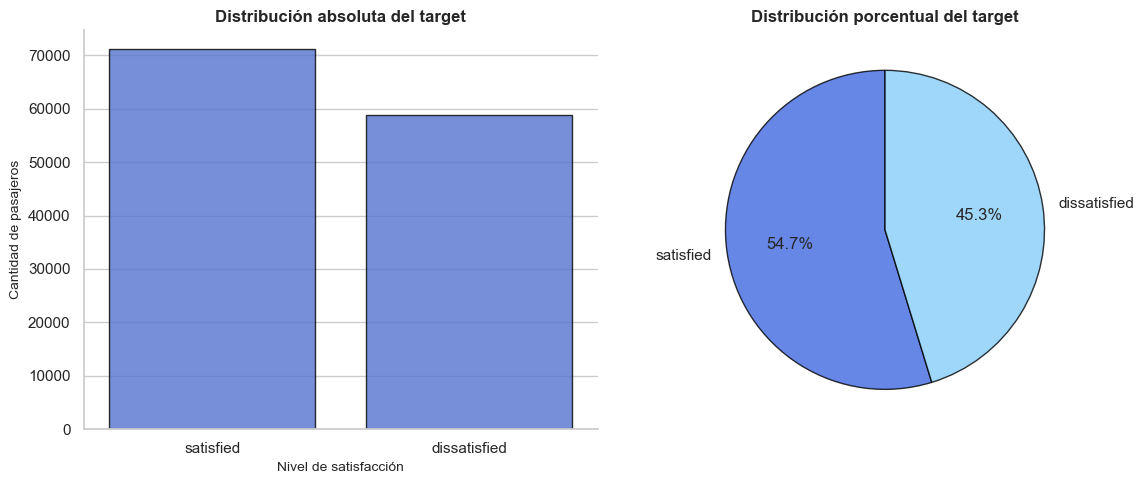

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

sns.countplot(
    data=df, 
    x='satisfaction', 
    ax=axes[0], 
    color='royalblue', 
    alpha=0.8, 
    edgecolor='black'
)
axes[0].set_title('Distribución absoluta del target', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Nivel de satisfacción', fontsize=10)
axes[0].set_ylabel('Cantidad de pasajeros', fontsize=10)

target_pct = df['satisfaction'].value_counts() 
axes[1].pie(
    target_pct, 
    labels=target_pct.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['royalblue', 'lightskyblue'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'alpha': 0.8} 
)
axes[1].set_title('Distribución porcentual del target', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Satisfaction**
Distribución absoluta y porcentual: Al observar los gráficos correspondientes al target, confirmamos que estamos ante un problema de clasificación binaria. La distribución muestra un total de 71.087 pasajeros que evaluaron positivamente su experiencia (satisfied), frente a 58.793 pasajeros que declararon estar insatisfechos (dissatisfied). En términos porcentuales, esto representa un 54.7% de clientes satisfechos frente a un 45.3% de insatisfechos

Balanceo de clases (Insight para el modelado): El hallazgo analítico más importante de esta visualización es que el dataset se encuentra muy bien balanceado. Al no existir una proporción de clases extrema (como un escenario de 90% a 10%), garantizamos que los algoritmos de machine learning que se entrenarían en etapas posteriores podrían aprender los patrones de ambas categorías por igual, sin generar un sesgo predictivo hacia una clase mayoritaria. Por lo tanto, se concluye que no sería estrictamente necesario aplicar métodos de remuestreo (como Oversampling o Undersampling) para tratar los datos antes de entrenar nuestros modelos predictivos.

---
## Análisis e imputación de valores nulos

In [11]:
print("Valores nulos por variable:")
print(df.isnull().sum())

Valores nulos por variable:
satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


In [12]:
print('Valores nulos de Arrival Delay in Minutes a imputar en Fase 1:', df['Arrival Delay in Minutes'].isnull().sum())


Valores nulos de Arrival Delay in Minutes a imputar en Fase 1: 393


Al inspeccionar la información general del dataset mediante df.info(), identificamos que la variable Arrival Delay in Minutes es la única que presenta valores faltantes. Mientras que las 22 variables restantes cuentan con 129,880 registros válidos (100% completitud), esta variable específica registra únicamente 129,487 valores no nulos, lo que corresponde a 393 registros faltantes, representando apenas el 0.3% del dataset total. Para confirmar este hallazgo, procedimos a ejecutar un análisis detallado mediante print("Valores nulos por variable:") seguido de print(df.isnull().sum()), verificando que efectivamente Arrival Delay in Minutes es el único campo con datos incompletos.

Ante esta situación, consideramos dos estrategias principales: eliminar los 393 registros con valores faltantes o realizar una imputación. Optamos por la imputación por mediana como la aproximación más apropiada por varias razones fundamentales. En primer lugar, eliminar el 0.3% del dataset representaría una pérdida innecesaria de información y reducción del poder predictivo de los modelos, considerando que contamos con aproximadamente 130,000 observaciones. En segundo lugar, la variable Arrival Delay in Minutes ha demostrado ser predictivamente relevante en nuestro análisis exploratorio, mostrando diferencias significativas entre pasajeros satisfechos (media de 12.27 minutos) e insatisfechos (media de 18.50 minutos), por lo que mantener el máximo de registros es estratégicamente importante.

La mediana de Arrival Delay in Minutes es 0 minutos, lo cual resulta semanticamente correcto y realista. Este valor representa la realidad operacional de que la mayoría de vuelos llegan sin retrasos significativos, y asignar 0 minutos a los registros faltantes constituye una imputación conservadora que no introduce sesgo sistemático en la distribución. Además, la mediana es más robusta que la media ante la presencia de retrasos extremos (outliers en la cola superior de la distribución), lo que minimiza la distorsión de la variable.

Por lo anterior, procederemos a imputar los 393 valores faltantes de Arrival Delay in Minutes con su mediana (0 minutos), asegurando que el dataset completo de 129,880 registros estuviese disponible para las etapas subsecuentes de modelado y validación.

--- 
## Análisis de outliers

<Figure size 640x480 with 0 Axes>

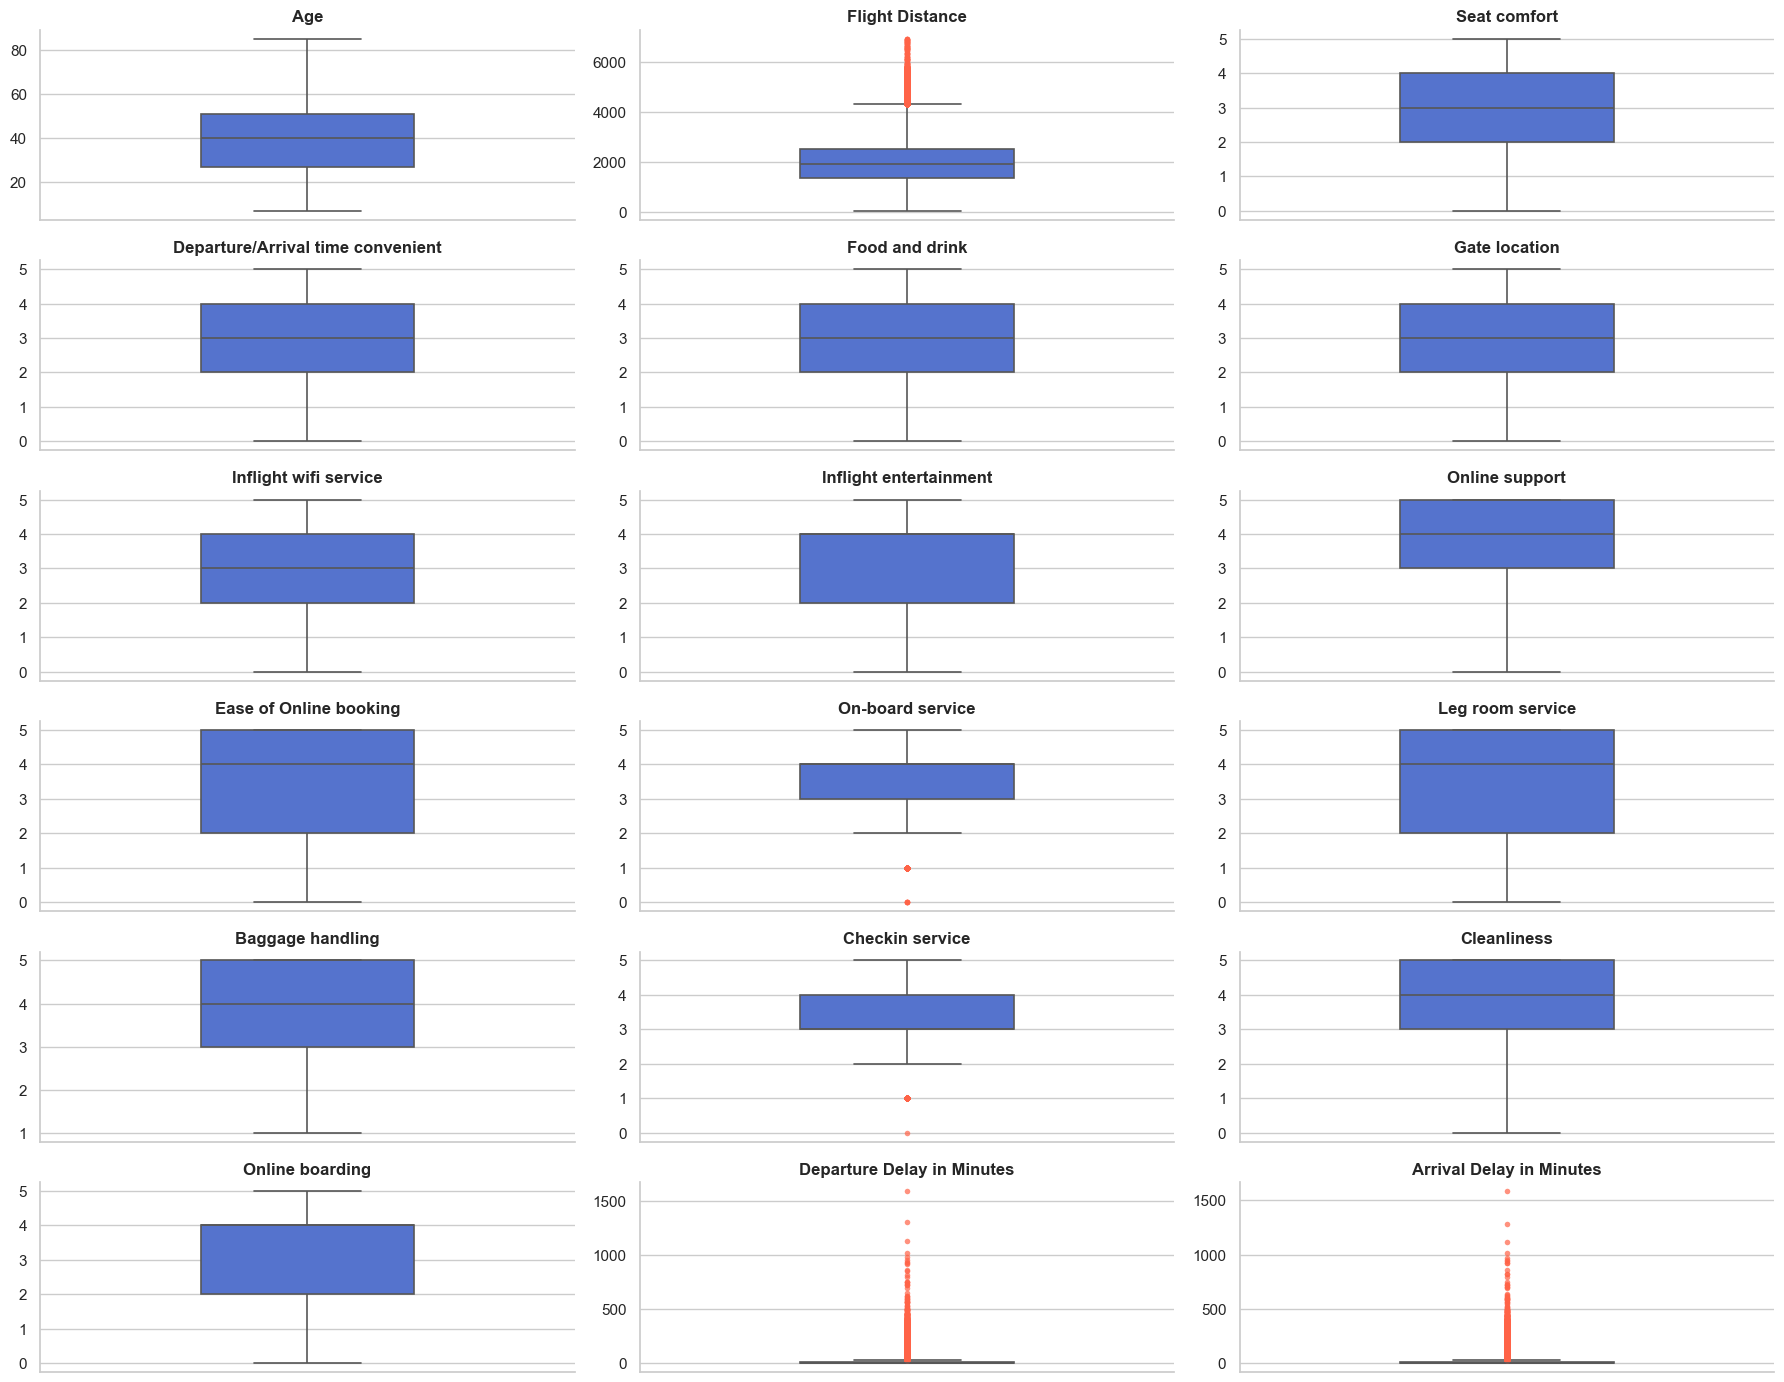

In [13]:
plt.suptitle('Boxplots para detección de outliers\n', fontsize=16, fontweight='bold')
plot_distributions(df, numeric_cols, kind='box', color='royalblue', width=0.4, linewidth=1.2, flierprops={'marker': 'o', 'markerfacecolor': 'tomato', 'markersize': 4, 'alpha': 0.7, 'markeredgecolor': 'none'})


In [14]:
print("Método IQR")

def outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

outliers_dict = {}
for col in numeric_cols:
    outliers, lower, upper = outliers_iqr(df[col])
    n_outliers = outliers.sum()
    pct_outliers = (n_outliers / len(df)) * 100
    
    if n_outliers > 0:
        print(f"\n{col}:")
        print(f"  Límite inferior: {lower:.2f}")
        print(f"  Límite superior: {upper:.2f}")
        print(f"  Cantidad de outliers: {n_outliers} ({pct_outliers:.2f}%)")
        outliers_dict[col] = n_outliers

Método IQR

Flight Distance:
  Límite inferior: -418.50
  Límite superior: 4321.50
  Cantidad de outliers: 2581 (1.99%)

On-board service:
  Límite inferior: 1.50
  Límite superior: 5.50
  Cantidad de outliers: 13270 (10.22%)

Checkin service:
  Límite inferior: 1.50
  Límite superior: 5.50
  Cantidad de outliers: 15370 (11.83%)

Departure Delay in Minutes:
  Límite inferior: -18.00
  Límite superior: 30.00
  Cantidad de outliers: 18098 (13.93%)

Arrival Delay in Minutes:
  Límite inferior: -19.50
  Límite superior: 32.50
  Cantidad de outliers: 17492 (13.47%)


Durante el análisis exploratorio, aplicamos el método del Rango Intercuartílico (IQR) para la detección de valores extremos, utilizando como límites Q1 - 1.5IQR y Q3 + 1.5IQR. Este análisis reveló la presencia de outliers en cinco variables del dataset, sin embargo, en ningún caso consideramos que estos representasen errores de registro o anomalías que justificasen su eliminación. **Flight Distance** registró 2,581 outliers (1.99% del dataset), correspondientes a vuelos excepcionalmente largos que exceden los 4,321.50 kilómetros, lo cual es completamente válido en operaciones aeroportuarias internacionales de largo alcance. Las variables de evaluación de servicios **On-board service** y **Checkin service** presentaron 13,270 y 15,370 outliers respectivamente (10.22% y 11.83%), consistiendo en calificaciones de 0 o 5 puntos, que representan opiniones extremas pero legítimas de pasajeros altamente satisfechos o muy insatisfechos. De manera similar, los delays presentaron cantidades considerables de outliers: 18,098 registros en **Departure Delay in Minutes** (13.93%) y 17,492 en **Arrival Delay in Minutes** (13.47%), correspondientes a retrasos superiores a 30 minutos, que constituyen eventos operacionales reales y potencialmente críticos para explicar la insatisfacción del cliente.

La decisión de mantener todos los outliers identificados se fundamenta en su validez operacional y su potencial predictivo. Los extremos en variables de servicio son información discriminativa valiosa que refleja experiencias auténticas de clientes muy satisfechos o muy insatisfechos, precisamente los grupos que los modelos necesitarían identificar con precisión. Los outliers en distancias de vuelo representan una diversidad legítima en la cartera de rutas de la aerolínea. Los retrasos extremos, aunque infrecuentes, son eventos reales que sabemos impactan significativamente la satisfacción del cliente. Eliminar estos valores distorsionaría la representatividad de los modelos y los haría menos efectivos para predecir situaciones problemáticas en escenarios reales. Por estas razones, decidimos mantener la totalidad de los outliers en el dataset, evitando una limpieza excesiva que podría eliminar información valiosa sobre los patrones de insatisfacción que buscamos predecir.

--- 
## Relación de features con el target

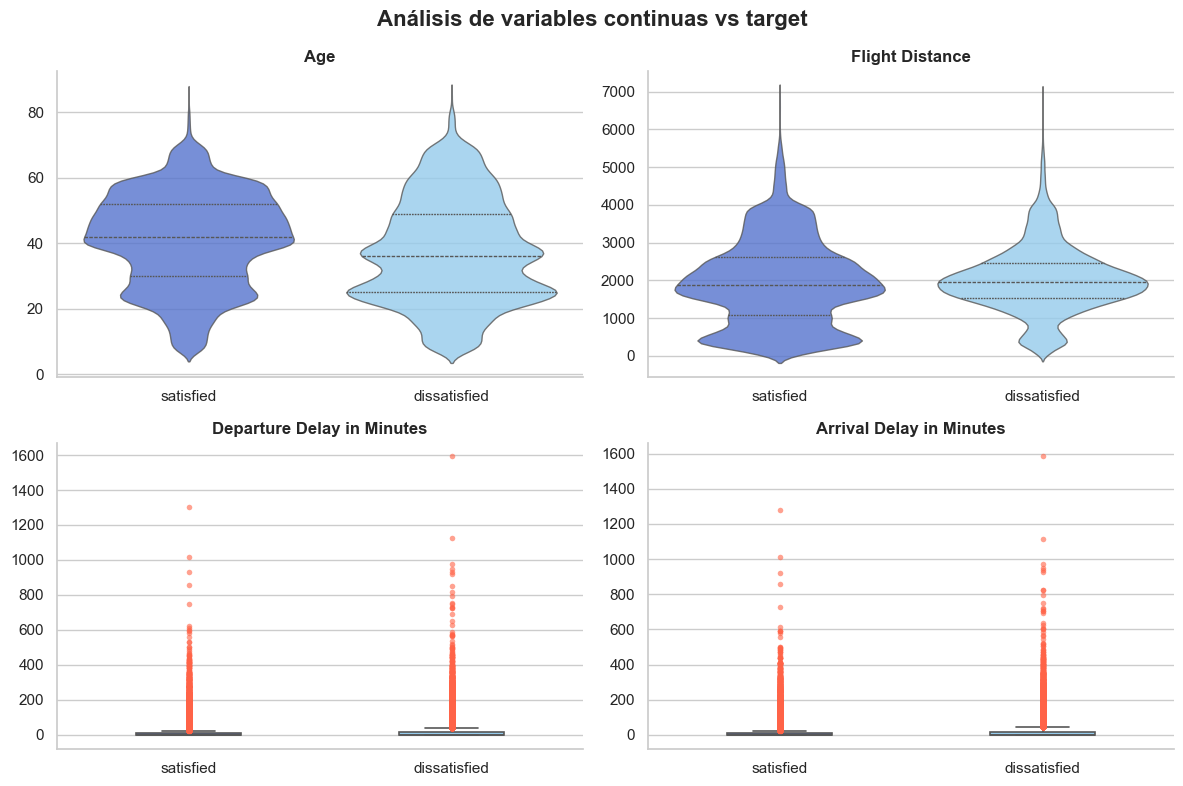

In [15]:
continuous_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes1.flatten(), continuous_cols):
    if col in ['Age', 'Flight Distance']:
        sns.violinplot(
            data=df, 
            x='satisfaction', 
            y=col, 
            hue='satisfaction',
            legend=False,      
            ax=ax,
            palette=['royalblue', 'lightskyblue'],
            inner='quartile', 
            alpha=0.8,
            linewidth=1
        )
    else:
        sns.boxplot(
            data=df, 
            x='satisfaction', 
            y=col, 
            hue='satisfaction', 
            legend=False,      
            ax=ax,
            palette=['royalblue', 'lightskyblue'],
            width=0.4,
            linewidth=1.2,
            flierprops={'marker': 'o', 'markerfacecolor': 'tomato', 'markersize': 4, 'alpha': 0.6, 'markeredgecolor': 'none'}
        )
        
    ax.set_title(f'{col}', fontweight='bold', fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle('Análisis de variables continuas vs target', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

**Age**: El violinplot revela patrones de distribución distintos entre grupos de satisfacción. Los pasajeros insatisfechos presentan una distribución cuya mayor concentración y anchura se encuentra en el rango etario entre los 20 y 40 años, extendiéndose en menor medida hacia edades más avanzadas. Esto sugiere que los clientes jóvenes y adultos jóvenes tienden a experimentar insatisfacción con mayor frecuencia. En contraste, los pasajeros satisfechos muestran una distribución más concentrada y simétrica, con la mayor densidad ubicada en el rango de 40 a 50 años. La mediana de edad para pasajeros satisfechos es notablemente superior a la de insatisfechos, indicando que los clientes de mediana edad (40-50 años) tienen mayor probabilidad de estar satisfechos. Este patrón puede reflejar que clientes más experimentados en viajes tienen expectativas más realistas, o que este grupo etario tiene mayor poder adquisitivo para acceder a servicios de mejor calidad.

**Flight Distance**: Los violinplots para ambos grupos presentan formas notablemente similares en amplitud y distribución. Las líneas de mediana para satisfechos e insatisfechos se encuentran aproximadamente al mismo nivel, cercanas a 1,900-2,000 kilómetros. Ambos grupos muestran la misma estructura: concentración en vuelos cortos a medios (500-2,500 km) con una cola que se extiende hacia vuelos largos (hasta 7,000 km). La ausencia de una polarización clara entre grupos sugiere que la distancia del vuelo tiene un impacto débil en la satisfacción general del cliente. A diferencia de variables de servicio que muestran separaciones nítidas entre satisfechos e insatisfechos, la distancia no discrimina fuertemente entre ambos grupos. Este hallazgo es importante para el modelado, ya que indica que el tipo de ruta (corta o larga) es un factor menos predictivo que la calidad de los servicios prestados durante el vuelo.

**Departure Delay in Minutes**: El boxplot revela que la mediana de retrasos es aproximadamente 0 minutos para ambos grupos, reflejando que la mayoría de vuelos salen a tiempo. Sin embargo, existen diferencias importantes en la cola de la distribución. Los pasajeros insatisfechos presentan un tercer cuartil y bigotes superiores ligeramente más amplios, indicando que experimentan retrasos de mayor duración con más frecuencia que los pasajeros satisfechos. Los valores atípicos extremos (hasta 1,600 minutos) aparecen en ambos grupos pero con mayor densidad en insatisfechos, lo cual permite formular la hipótesis de negocio de que los retrasos prolongados contribuyen negativamente a la satisfacción general del vuelo. Sin embargo, la proximidad de las medianas sugiere que el retraso no es el factor determinante principal de insatisfacción, sino un contribuyente entre varios.

**Arrival Delay in Minutes**: El patrón es prácticamente idéntico al de retrasos de salida. La mediana nuevamente es cercana a 0 para ambos grupos, con los pasajeros insatisfechos mostrando una dispersión ligeramente mayor en la cola superior. Los valores atípicos extremos (hasta 1,600 minutos) aparecen en ambos grupos. Este resultado refuerza que los retrasos son un factor de insatisfacción, pero no el único determinante. Los modelos predictivos necesitarían capturar esta relación junto con otros factores de servicio más críticos.

<Figure size 640x480 with 0 Axes>

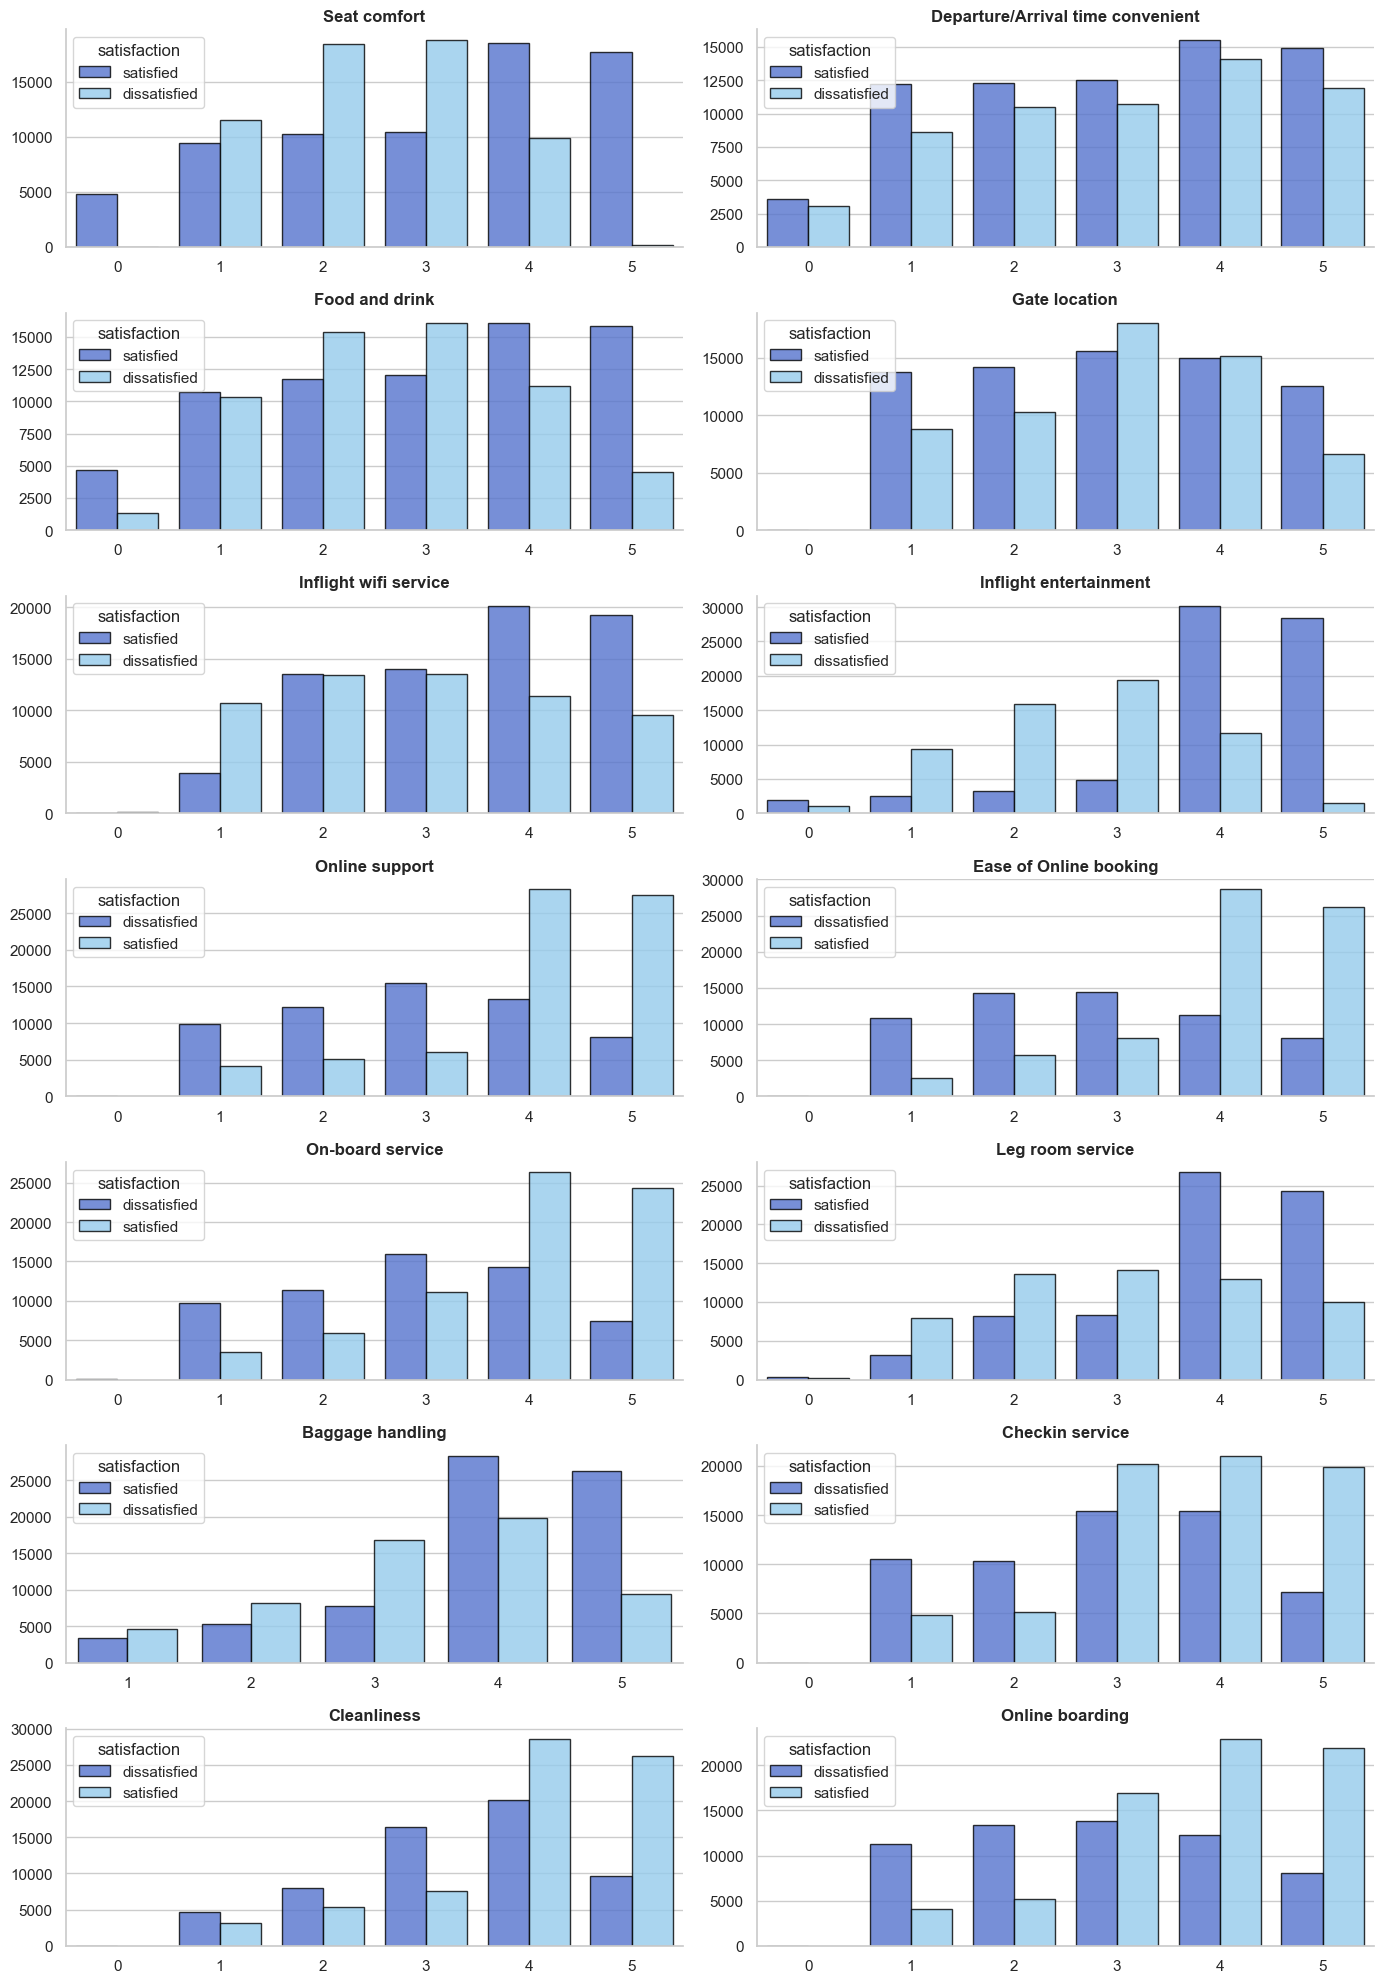

In [17]:
ordinal_cols = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 
    'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 
    'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 
    'Cleanliness', 'Online boarding'
]

plt.suptitle('Análisis de variables ordinales vs Target\n', fontsize=16, fontweight='bold')
plot_distributions(df, ordinal_cols, kind='count', target='satisfaction', palette=['royalblue', 'lightskyblue'], edgecolor='black', alpha=0.8, figsize=(14, 20), cols=2)


Servicios con tendencia directa (Mayor puntaje = Mayor satisfacción): Variables críticas relacionadas con el confort y el ocio muestran el comportamiento polarizado esperado. En características como **Seat comfort**, **Food and drink**, **Inflight wifi service**, **Inflight entertainment**, **Leg room service** y **Baggage handling** los pasajeros insatisfechos (barras celestes) son mayoría absoluta en las puntuaciones bajas (1, 2 y 3). Por el contrario, los pasajeros satisfechos (barras azul oscuro) dominan abrumadoramente las puntuaciones más altas (4 y 5). El entretenimiento a bordo y el wifi presentan una fuerte asociación estadística con altas valoraciones, lo que nos lleva a hipotetizar que actuarían como palancas clave para lograr una experiencia positiva,

Servicios con patrón inverso o anómalo: Un hallazgo sumamente interesante de este análisis exploratorio es el comportamiento inverso en un grupo específico de operativas. En variables como **Online support**, **Ease of Online booking**, **On-board service**, **Cleanliness**, **Checkin service**
y **Online boarding** observamos el escenario opuesto: los pasajeros satisfechos (azul oscuro) concentran su volumen en las puntuaciones bajas (1, 2 y 3), mientras que los pasajeros insatisfechos (celeste) son quienes registran las puntuaciones más altas (4 y 5). Este fenómeno sugiere dos posibles explicaciones de negocio: o bien la escala de la encuesta está invertida desde el origen de los datos para estas preguntas específicas (donde 1 es excelente y 5 es deficiente), o bien los pasajeros valoran estos servicios bajo un estándar distinto al resto.

Características neutrales: Finalmente, factores logísticos como **Departure/Arrival time convenient** y **Gate location** presentan distribuciones muy similares y equilibradas entre ambas clases a lo largo de todas las puntuaciones. Esto indica que la conveniencia del horario o la ubicación de la puerta de embarque no actúan como factores decisivos que inclinen la balanza hacia la satisfacción o insatisfacción general del pasajero en este conjunto de datos

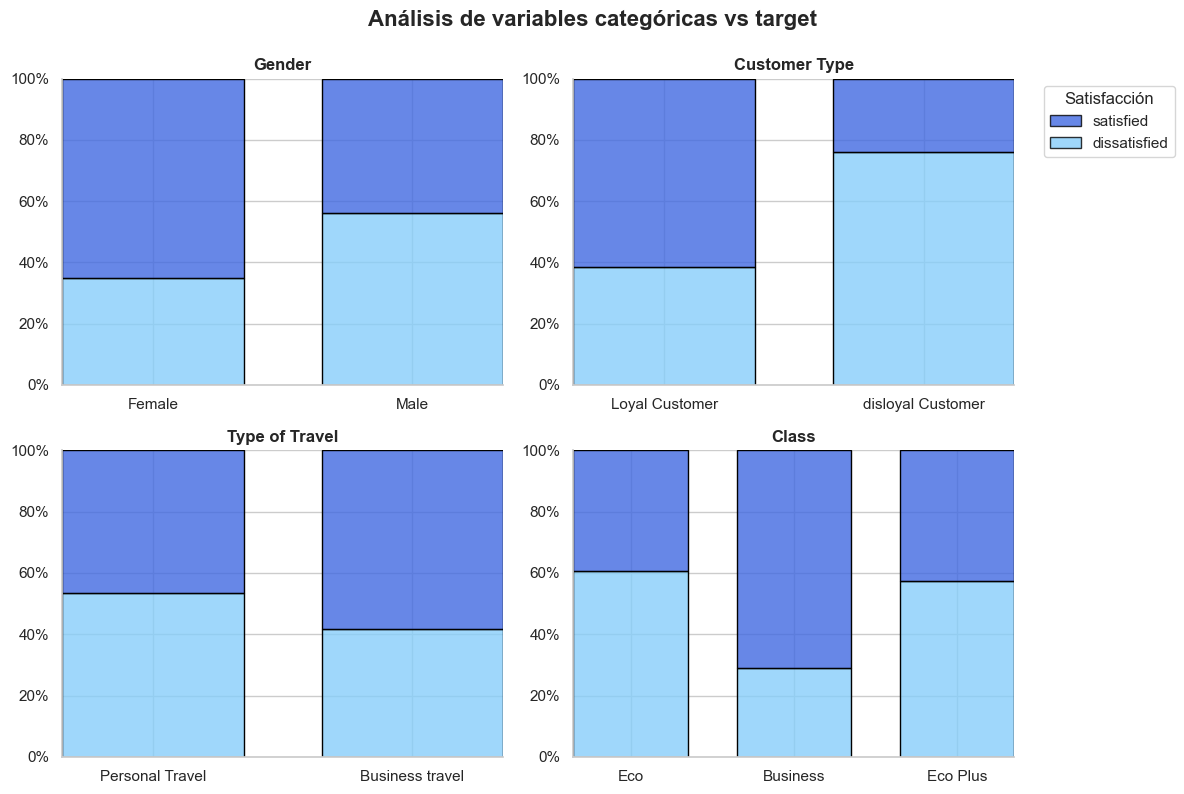

In [18]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.histplot(
        data=df, 
        x=col, 
        hue='satisfaction', 
        multiple='fill', 
        ax=axes_flat[idx], 
        palette=['royalblue', 'lightskyblue'], 
        edgecolor='black', 
        alpha=0.8,
        shrink=0.7 
    )
    
    axes_flat[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
    axes_flat[idx].set_xlabel("")
    axes_flat[idx].set_ylabel("")
    axes_flat[idx].yaxis.set_major_formatter(PercentFormatter(1.0))
    
    if axes_flat[idx].get_legend() is not None:
        axes_flat[idx].get_legend().remove()

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.8, ec='black') for c in ['royalblue', 'lightskyblue']]
labels = df['satisfaction'].unique().tolist() 

axes_flat[1].legend(handles=handles, labels=labels, title='Satisfacción', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Análisis de variables categóricas vs target', fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

**Gender**: El gráfico de barras apiladas revela una diferencia visual en la proporción de satisfacción según el género del pasajero. Las pasajeras (Female) presentan una tasa de satisfacción mayoritaria, ocupando aproximadamente el 65% de la barra. Por el contrario, los pasajeros masculinos (Male) muestran una tendencia inversa, donde la proporción de insatisfacción supera el 50%. Esta diferencia en las proporciones sugiere que, dentro de este conjunto de datos, la experiencia de vuelo o los servicios ofrecidos tienden a satisfacer en mayor medida al público femenino frente al masculino.

**Customer Type**: Se observa una marcada polarización entre los clientes leales y los ocasionales. Los pasajeros frecuentes o fidelizados (Loyal Customer) muestran una clara mayoría de clientes satisfechos (cerca del 60%). En contraste, el grupo de clientes no leales (disloyal Customer) presenta un patrón fuertemente dominado por la insatisfacción, la cual casi el 80% de su distribución. Este hallazgo visual indica que la fidelidad a la aerolínea está estrechamente ligada a una alta tasa de experiencias positivas, mientras que los clientes esporádicos tienden a tener experiencias predominantemente negativas.

**Type of Travel**: El motivo del viaje muestra un impacto visible en la propensión a estar satisfecho. Los pasajeros que viajan por motivos de negocios (Business travel) tienen una mayor proporción de satisfacción (alrededor del 60%). Por su parte, en los viajes personales (Personal Travel), la barra de insatisfacción supera levemente la mitad del gráfico. Este patrón sugiere que los viajeros corporativos experimentan un nivel de satisfacción superior, lo cual podría deberse a que sus expectativas son diferentes o a que sus pasajes suelen incluir beneficios y comodidades que los viajeros personales no suelen adquirir.

**Class** Este gráfico presenta la separación más nítida de todas las variables categóricas analizadas. Los pasajeros que vuelan en clase ejecutiva (Business) muestran un nivel de satisfacción superior, representando aproximadamente el 70% de su grupo. Por el contrario, las clases económica (Eco) y económica premium (Eco Plus) presentan distribuciones casi idénticas entre sí, donde la insatisfacción predomina claramente (rondando el 60%). Esta fuerte diferencia visual sugiere la hipótesis de que las comodidades y el espacio de la clase Business podrían ser los impulsores principales de una experiencia positiva. Se buscará validar si trasladar ciertas mejoras a las categorías inferiores lograría elevar sus tasas de satisfacción.

---
## Correlaciones entre variables

Correlaciones con el target
Satisfaction                         1.000
Inflight entertainment               0.523
Ease of Online booking               0.432
Online support                       0.390
On-board service                     0.352
Online boarding                      0.338
Leg room service                     0.305
Checkin service                      0.266
Baggage handling                     0.260
Cleanliness                          0.259
Seat comfort                         0.242
Inflight wifi service                0.227
Food and drink                       0.121
Age                                  0.118
Gate location                       -0.012
Departure/Arrival time convenient   -0.016
Flight Distance                     -0.039
Departure Delay in Minutes          -0.074
Arrival Delay in Minutes            -0.081
Name: Satisfaction, dtype: float64


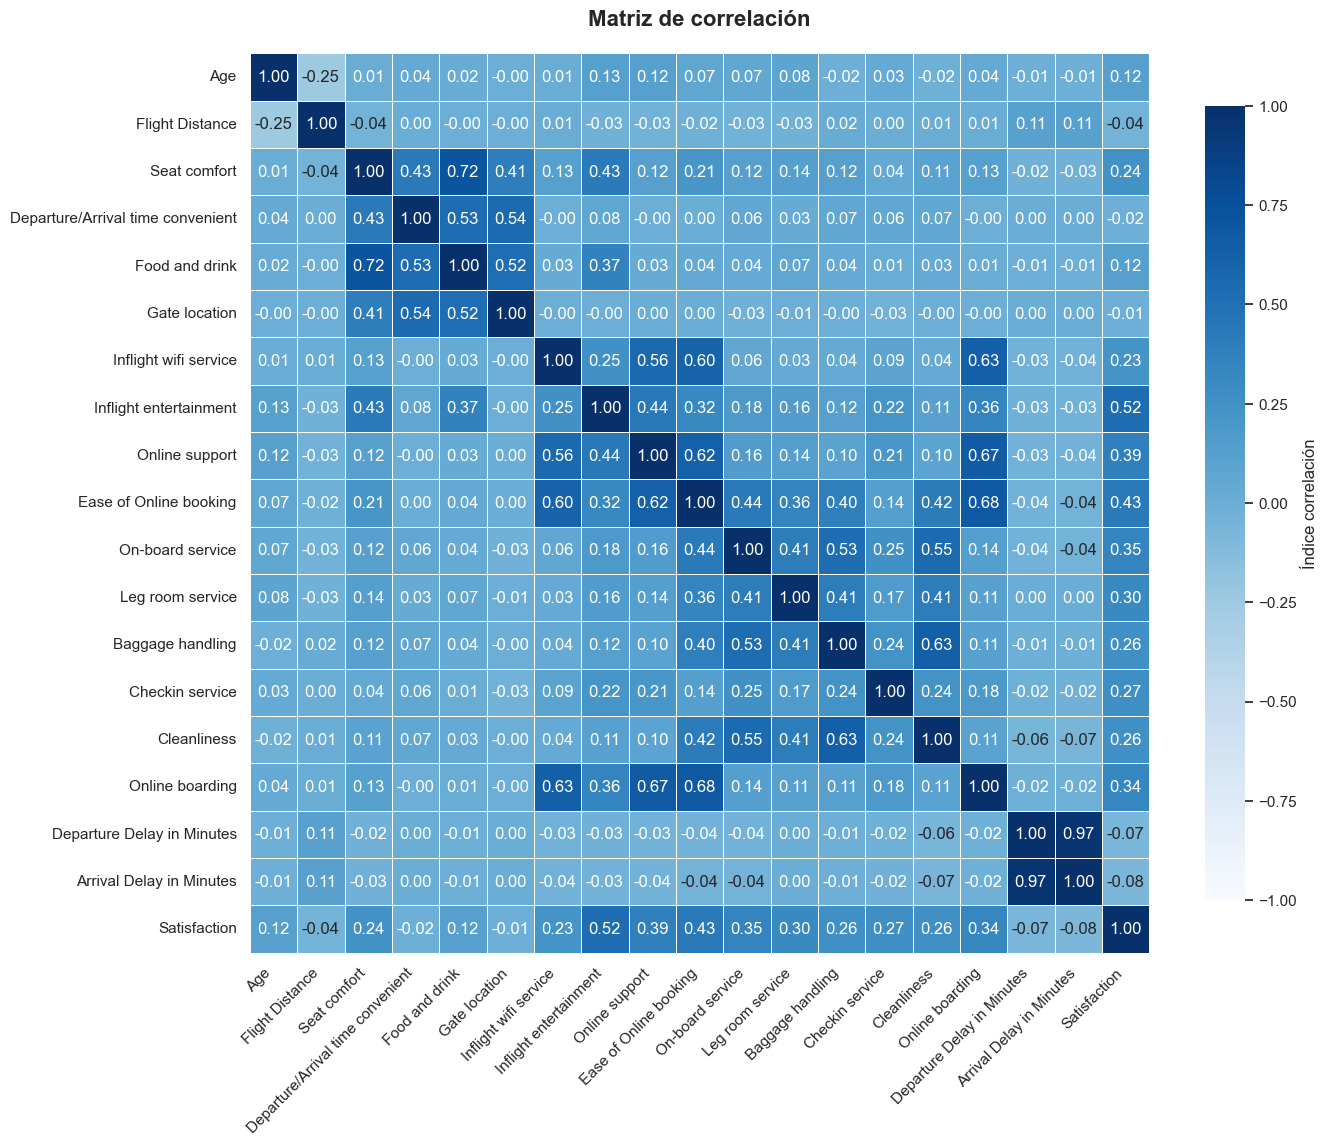

In [19]:
df_corr = df.assign(Satisfaction=(df['satisfaction'] == 'satisfied').astype(int))

cols_corr = numeric_cols + ['Satisfaction']
correlations = df_corr[cols_corr].corr()

print("Correlaciones con el target")
print(correlations['Satisfaction'].sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    correlations, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',        
    vmin=-1, vmax=1,       
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8, 'label': 'Índice correlación'}, 
    ax=ax
)

ax.set_title('Matriz de correlación', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

El análisis de la matriz de correlación revela de manera cuantitativa lo que el análisis bivariado mostró visualmente. 

**Inflight Entertainment**: 0.52 (Correlación Positiva Fuerte)
Este es sin lugar a dudas el predictor numérico más fuerte del dataset. Una correlación de 0.52 significa que existe una relación lineal moderada-fuerte entre la calidad del entretenimiento en vuelo y la satisfacción general. A medida que el entretenimiento mejora (en escala 0-5), la probabilidad de satisfacción aumenta significativamente. Este valor confirma visualmente lo que observamos en el countplot: la separación casi total entre grupos satisfechos e insatisfechos en esta variable. La magnitud de 0.52 es notablemente superior a cualquier otro predictor individual, justificando que sea el factor crítico en los modelos predictivos.

**Ease of Online Booking**: 0.43 (Correlación Positiva Moderada)
La facilidad para realizar reservas en línea muestra una correlación moderada de 0.43 con satisfacción. Esta relación es intuitiva: un cliente que tiene dificultades en el proceso de reserva comienza su experiencia con insatisfacción antes incluso de abordar el avión. Sin embargo, la magnitud es sustancialmente menor que entretenimiento, sugiriendo que mientras la facilidad de reserva importa, es menos determinante que la experiencia a bordo.

**Online Support**: 0.39 (Correlación Positiva Moderada)
El soporte en línea presenta una correlación de 0.39, similar a la facilidad de reserva. Clientes que pueden acceder a soporte efectivo reportan mayor satisfacción. El hecho de que esta correlación sea menor que entretenimiento pero similar a booking suggest que el soporte es un factor complementario que mejora la experiencia pero no es el elemento central.

**On-board Service**: 0.35 (Correlación Positiva Moderada-Débil)
Sorprendentemente, el servicio a bordo presenta una correlación de 0.35, inferior a las expectativas basadas en el análisis bivariado que mostraba buena separación entre grupos. Esto indica que aunque el servicio es importante, la magnitud de su relación lineal con satisfacción es moderada. Otros factores (especialmente entretenimiento) pueden estar capturando más varianza que el servicio a bordo por sí solo.

**Online Boarding**: 0.34 (Correlación Positiva Moderada-Débil)
El embarque en línea correlaciona con 0.34, indicando un impacto moderado. La facilidad de embarcar en línea contribuye a la satisfacción, pero nuevamente con menor fuerza que entretenimiento o facilidad de reserva.

**Leg Room Service**: 0.30 (Correlación Positiva Débil-Moderada)
El espacio para las piernas muestra una correlación de 0.30, reflejo de lo que vimos en los countplots: existe separación entre grupos pero con superposición. Algunos pasajeros pueden estar satisfechos a pesar de limitado espacio (especialmente si están en clase económica con expectativas ajustadas), y otros insatisfechos a pesar de adecuado espacio si otros aspectos del vuelo fallaron.

**Checkin Service**: 0.27 (Correlación Positiva Débil)
El servicio de check-in muestra una correlación débil de 0.27, consistente con la superposición observada entre grupos en los countplots. Es un factor complementario pero no central.

**Baggage Handling**: 0.26 (Correlación Positiva Débil)
El manejo de equipaje correlaciona débilmente con 0.26. Este es un servicio importante pero aparentemente no determinante de la satisfacción global. Los clientes pueden tolerar problemas menores con equipaje si el resto del vuelo fue excelente.

**Cleanliness**: 0.26 (Correlación Positiva Débil)
Sorprendentemente, la limpieza presenta una correlación de solo 0.26, inferior a lo esperado dado su impacto visual. Esto sugiere que aunque es un factor importante (especialmente para generar insatisfacción), su correlación lineal es débil. Esto podría indicar que la limpieza es un requisito básico (higiene mínima esperada) pero su mejora no aumenta proporcionalmente la satisfacción. En términos de negocio, esto nos permite formular la hipótesis de que la limpieza funciona como un 'factor higiénico': asumiendo que un avión sucio probablemente ocasione insatisfacción directa, pero un avión limpio simplemente cumple con la expectativa base, sin actuar como un gran diferenciador.

**Seat comfort**: 0.24 (Correlación Positiva Débil) 
Indica que existe una relación directa o positiva: a medida que aumenta la valoración del confort, tiende a aumentar la probabilidad de satisfacción. Sin embargo, la magnitud nos indica que la fuerza de esta relación es débil y presenta dispersión. Esto nos señala que el confort del asiento es un factor que suma a la experiencia, pero no es lo suficientemente fuerte como para ser el predictor principal o único de la satisfacción del cliente.

**Inflight Wifi Service**: 0.23 (Correlación Positiva Débil)
El wifi en vuelo correlaciona con 0.23, menor de lo que el countplot sugería visualmente. Esto indica que aunque hay separación entre grupos, la relación no es linealmente fuerte. La disponibilidad de wifi importa para algunos pasajeros (especialmente viajeros de negocios) pero muchos pasajeros pueden estar satisfechos sin necesitarlo.

**Food and Drink**: 0.12 (Correlación Positiva Muy Débil)
La comida y bebida presenta una correlación sorprendentemente baja de 0.12, indicando que su relación lineal con satisfacción es minimal. Aunque mostró polarización en el countplot, la correlación sugiere que muchos otros factores confunden esta relación. La comida podría ser importante para algunos pasajeros pero irrelevante para otros.

**Age**: 0.12 (Correlación Positiva Muy Débil)
La edad muestra una correlación de solo 0.12 con satisfacción, indicando que la relación es débil. A pesar de la distribución bimodal observada en insatisfechos, la edad no es un predictor fuerte de satisfacción general. Clientes de todas las edades pueden estar satisfechos e insatisfechos.

**Gate Location**: -0.01 (Correlación Negativa Negligible)
La ubicación de la puerta correlaciona con -0.01, prácticamente sin relación alguna con satisfacción. Este factor logístico no afecta la experiencia del pasajero de manera significativa.

**Departure/Arrival Time Convenient**: -0.02 (Correlación Negativa Negligible)
La conveniencia del horario presenta una correlación prácticamente nula de -0.02, confirmando que este factor tiene impacto insignificante en la satisfacción. Los clientes no seleccionan sus vuelos principalmente por el horario cuando su objetivo es viajar, y una vez a bordo, el horario es irrelevante.

**Flight Distance**: -0.04 (Correlación Negativa Muy Débil)
La distancia del vuelo muestra una correlación negativa de -0.04, indicando ausencia de relación. Los vuelos cortos no son más probables de generar insatisfacción que los vuelos largos, y viceversa.

**Departure Delay in Minutes**: -0.07 (Correlación Negativa Débil)
Los retrasos de salida presentan una correlación negativa débil de -0.07. El signo negativo es correcto: más retrasos asociados con menos satisfacción. Sin embargo, la magnitud débil indica que los retrasos no son la causa principal de insatisfacción. Muchos vuelos con retrasos pueden terminar satisfaciendo al cliente si el resto de la experiencia es buena, o vuelos sin retrasos pueden insatisfacer si los servicios a bordo fallan.

**Arrival Delay in Minutes**: -0.08 (Correlación Negativa Débil)
Los retrasos de llegada correlacionan débilmente con -0.08, prácticamente idéntico a retrasos de salida. Como se esperaba por su correlación de 0.96 entre ellos, proporcionan información redundante y predeciblemente similar.

*Correlaciones Muy Altas (r > 0.90)*:
**Departure Delay in Minutes** y **Arrival Delay in Minutes**: 0.96
Esta es la multicolinealidad más crítica identificada. Ambas variables capturan esencialmente la misma información: el tiempo total de espera del pasajero.

*Correlaciones Altas (r > 0.60)*:
**Seat comfort** y **Food and drink**: 0.72 
Refleja una tendencia fuerte entre ambas características. A nivel de negocio, este hallazgo es muy valioso: los pasajeros que evalúan positivamente el confort de su asiento también tienden fuertemente a evaluar bien la comida y bebida, y viceversa. Esto sugiere que la experiencia física dentro de la cabina podría ser percibida por el cliente como un todo. Como hipótesis de negocio, planteamos que si la aerolínea invirtiera en mejorar uno de estos servicios, podría generar un 'efecto halo' mejorando la percepción del otro. Alternativamente, esta correlación podría simplemente reflejar que la aerolínea mantiene un estándar unificado en su presupuesto de cabina. Esto deberá validarse con pruebas de campo.

**Online boarding** y **Ease of Online booking**: 0.68 
Este comportamiento nos confirma que el pasajero evalúa el ecosistema digital de la aerolínea (reserva, soporte y embarque) de manera unificada. Una plataforma que es intuitiva para comprar pasajes se traduce en una experiencia de usuario igualmente fluida a la hora de embarcar, lo que habla de una buena estandarización tecnológica de cara al usuario.

**Online boarding** y **Online support**: 0.67 
Este patrón indica que la calidad de la asistencia virtual impacta directamente en el éxito de los procesos digitales del pasajero. Quienes califican bien la asistencia (support) también logran una gran experiencia haciendo su embarque digital (boarding), lo que sugiere que un buen soporte resuelve eficazmente los posibles problemas o dudas durante el proceso de embarque.

**Inflight Wifi Service** y **Online Boarding**: 0.63
El wifi y el embarque en línea correlacionan con 0.63, posiblemente reflejando que ambos son servicios digitales modernos ofrecidos juntos en determinadas rutas o aeronaves.

**Online Support** y **Inflight Entertainment**: 0.56
Una correlación de 0.56 entre soporte en línea y entretenimiento sugiere que estas son características de sistemas modernos de servicio al cliente, probablemente correlacionadas con el tipo de aeronave o ruta.

**Ease of Online Booking** y **Online Support**: 0.62
La facilidad de reserva y soporte en línea correlacionan con 0.62, sugiriendo que sistemas modernos de booking tienden a incluir soporte integrado.

**Ease of Online Booking** y **Inflight Entertainment**: 0.60
Una correlación de 0.60 entre facilidad de reserva y entretenimiento probablemente refleja que las aerolíneas modernas con sistemas de reserva sofisticados tienden a tener también entretenimiento mejorado.

El análisis de la matriz de correlación proporciona tres conclusiones clave:
* Inflight Entertainment es dominante. Con una correlación de 0.52 y sin competencia cercana de otras variables, debe tener un peso significativo en cualquier modelo predictivo. Su importancia no puede subestimarse.
* Multicolinealidad moderada existe pero es manejable. La correlación de 0.96 entre delays requiere eliminación de una variable (Departure Delay). Las otras correlaciones altas (0.60-0.68) entre variables de servicio son informativas pero no requieren eliminación, sugieren que capturan aspectos complementarios de la calidad del servicio.
* Muchas variables muestran correlaciones débiles (< 0.30). Variables como Age, Food and Drink, Inflight Wifi, Cleanliness, y los factores logísticos presentan correlaciones débiles, sugiriendo que su poder predictivo es limitado individualmente. Sin embargo, estos factores pueden aún ser útiles cuando se combinan con otros en un modelo multivariado más complejo que capture interacciones no-lineales que una matriz de correlación lineal no puede detectar.

Top 10 Variables por Información Mutua (Relaciones Lineales y No Lineales):


Inflight entertainment    0.236015
Seat comfort              0.144145
Ease of Online booking    0.112249
Online support            0.102469
On-board service          0.073273
Online boarding           0.067706
Leg room service          0.060004
Baggage handling          0.054409
Class                     0.053474
Cleanliness               0.051775
Name: MI Scores, dtype: float64

C:\Users\Agustina\AppData\Local\Temp\ipykernel_6224\2142212039.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores_series.head(10).values, y=mi_scores_series.head(10).index, palette='viridis')


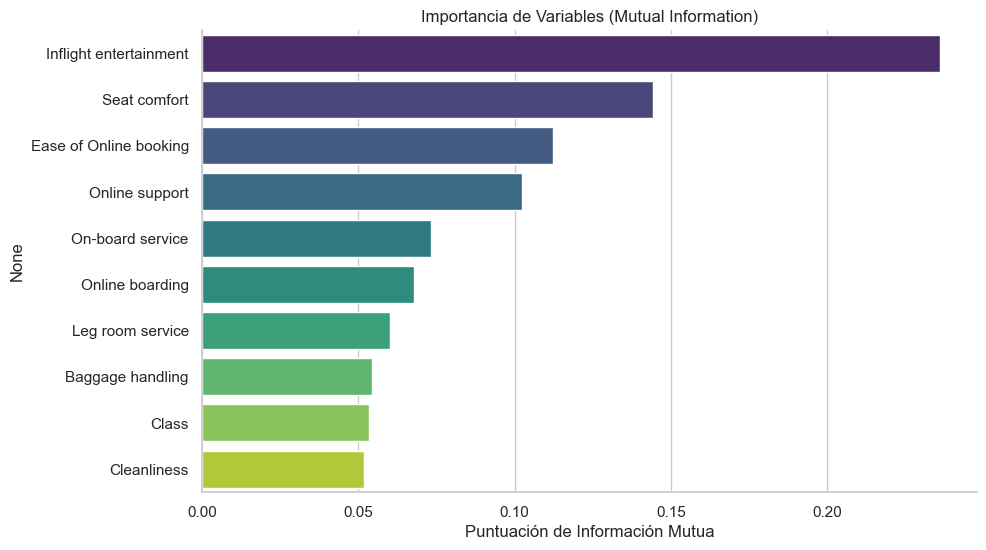

In [20]:
# Evaluación de Información Mutua (Mutual Information)
# Pearson asume linealidad. Mutual Information captura relaciones no lineales que son clave para Random Forest/XGBoost.
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# Preparamos un subconjunto sin nulos temporario solo para calcular MI
df_mi = df.dropna().copy()
X_mi = df_mi.drop(columns=['satisfaction'])
y_mi = (df_mi['satisfaction'] == 'satisfied').astype(int)

# Convertimos categóricas a numéricas simples (Label Encoding básico) solo para este cálculo exploratorio
for col in X_mi.select_dtypes(include=['object']).columns:
    X_mi[col] = X_mi[col].astype('category').cat.codes

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_scores_series = pd.Series(mi_scores, name='MI Scores', index=X_mi.columns)
mi_scores_series = mi_scores_series.sort_values(ascending=False)

print("Top 10 Variables por Información Mutua (Relaciones Lineales y No Lineales):")
display(mi_scores_series.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.head(10).values, y=mi_scores_series.head(10).index, palette='viridis')
plt.title('Importancia de Variables (Mutual Information)')
plt.xlabel('Puntuación de Información Mutua')
plt.show()
